# 1. Iris 데이터 KNN 품종 분류

붓꽃 데이터(Iris)를 이용해 KNN으로 품종을 분류
분석 순서: 데이터 준비 → EDA → 전처리 → 모델링 → 평가

## 1. 패키지

In [1]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

## 2. 데이터 준비

Iris 데이터셋 — 150개 샘플, 피처 4개, 품종 3종
- sepal length / sepal width / petal length / petal width (cm)
- 타겟: setosa(0), versicolor(1), virginica(2)

In [2]:
iris = load_iris()

FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
COLORS   = {'Setosa': '#E74C3C', 'Versicolor': '#3498DB', 'Virginica': '#2ECC71'}

df = pd.DataFrame(iris.data, columns=FEATURES)
df['species']      = iris.target
df['species_name'] = df['species'].map({0:'Setosa', 1:'Versicolor', 2:'Virginica'})

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# 결측치 확인
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
species_name    0
dtype: int64

In [5]:
# 품종별 샘플 수
df['species_name'].value_counts()

species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

## 3. EDA

분포, 이상치, 피처 간 관계를 먼저 파악

In [6]:
# 왜도 / 첨도 / IQR 이상치
stat = pd.DataFrame({
    'mean':     df[FEATURES].mean(),
    'std':      df[FEATURES].std(),
    'skewness': df[FEATURES].skew(),
    'kurtosis': df[FEATURES].kurtosis(),
}).round(3)

outlier_cnt = {}
for f in FEATURES:
    Q1, Q3 = df[f].quantile(0.25), df[f].quantile(0.75)
    IQR = Q3 - Q1
    outlier_cnt[f] = int(((df[f] < Q1-1.5*IQR) | (df[f] > Q3+1.5*IQR)).sum())
stat['outliers(IQR)'] = pd.Series(outlier_cnt)

print(stat)

               mean    std  skewness  kurtosis  outliers(IQR)
sepal_length  5.843  0.828     0.315    -0.552              0
sepal_width   3.057  0.436     0.319     0.228              4
petal_length  3.758  1.765    -0.275    -1.402              0
petal_width   1.199  0.762    -0.103    -1.341              0


In [7]:
# 품종별 피처 평균
df.groupby('species_name')[FEATURES].mean().round(3)

,sepal_length,sepal_width,petal_length,petal_width
species_name,,,,
Setosa,5.006,3.428,1.462,0.246
Versicolor,5.936,2.770,4.260,1.326
Virginica,6.588,2.974,5.552,2.026


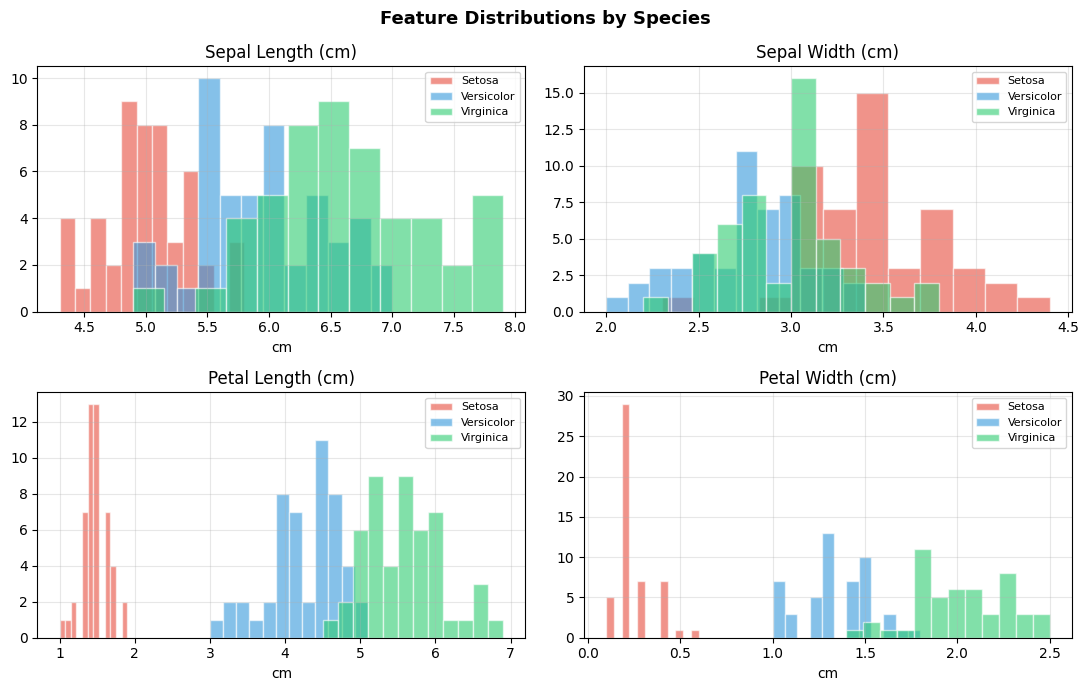

In [8]:
# 히스토그램 — 분포 형태 확인
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
labels = ['Sepal Length (cm)', 'Sepal Width (cm)', 'Petal Length (cm)', 'Petal Width (cm)']

for ax, feat, label in zip(axes.flatten(), FEATURES, labels):
    for sp, color in COLORS.items():
        ax.hist(df[df['species_name']==sp][feat], bins=12,
                alpha=0.6, color=color, label=sp, edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('cm')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Feature Distributions by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# petal 피처는 품종별로 분포가 명확하게 분리됨
# sepal_width는 세 품종이 많이 겹침

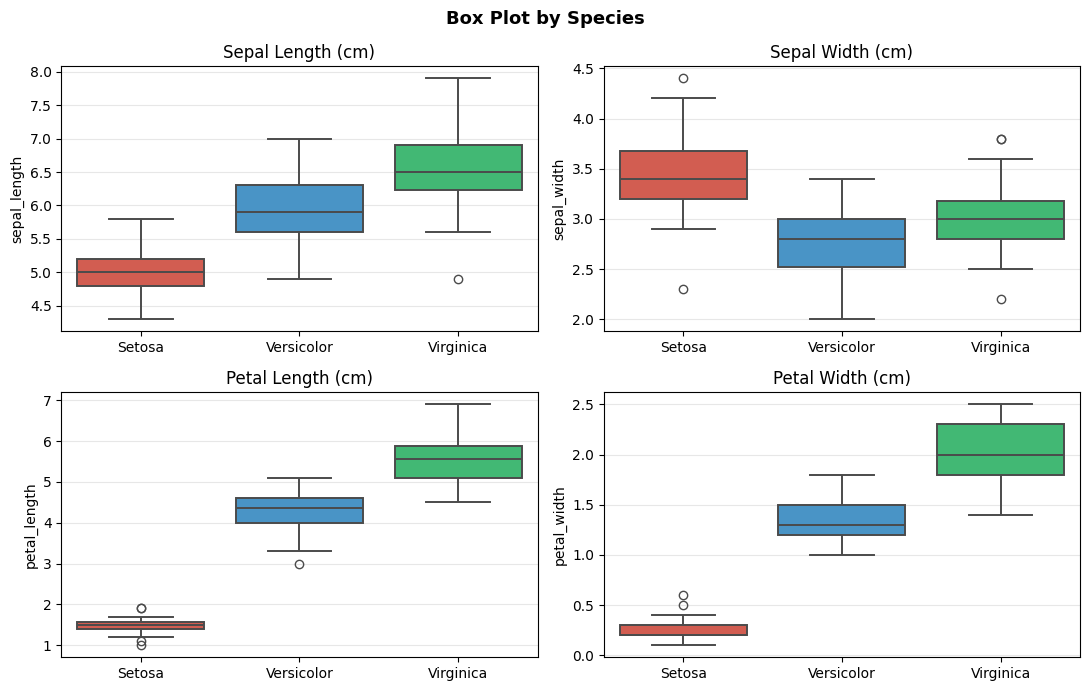

In [9]:
# 박스플롯 — 이상치 위치 파악
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, feat, label in zip(axes.flatten(), FEATURES, labels):
    sns.boxplot(
        data=df, x='species_name', y=feat,
        hue='species_name', palette=COLORS,
        order=['Setosa','Versicolor','Virginica'],
        legend=False, linewidth=1.4, ax=ax
    )
    ax.set_title(label)
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Box Plot by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# sepal_width에 이상치(원형 점)가 존재 — IQR 기준 4개

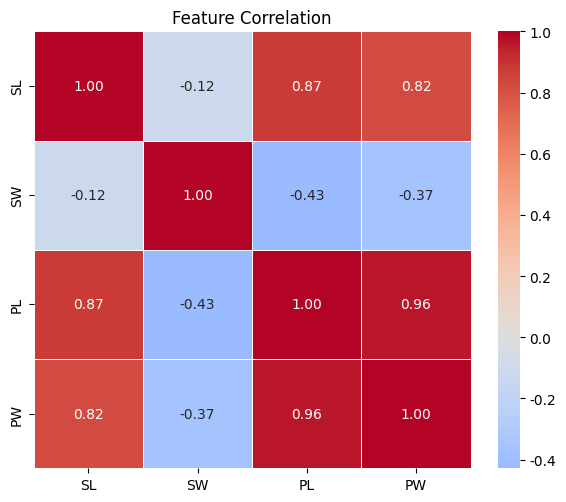

petal_length <-> petal_width: 0.963
sepal_width  <-> petal_length: -0.428


In [10]:
# 상관관계 히트맵
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            xticklabels=['SL','SW','PL','PW'],
            yticklabels=['SL','SW','PL','PW'], ax=ax)
ax.set_title('Feature Correlation', fontsize=12)
plt.tight_layout()
plt.show()

print(f'petal_length <-> petal_width: {corr.loc["petal_length","petal_width"]:.3f}')
print(f'sepal_width  <-> petal_length: {corr.loc["sepal_width","petal_length"]:.3f}')

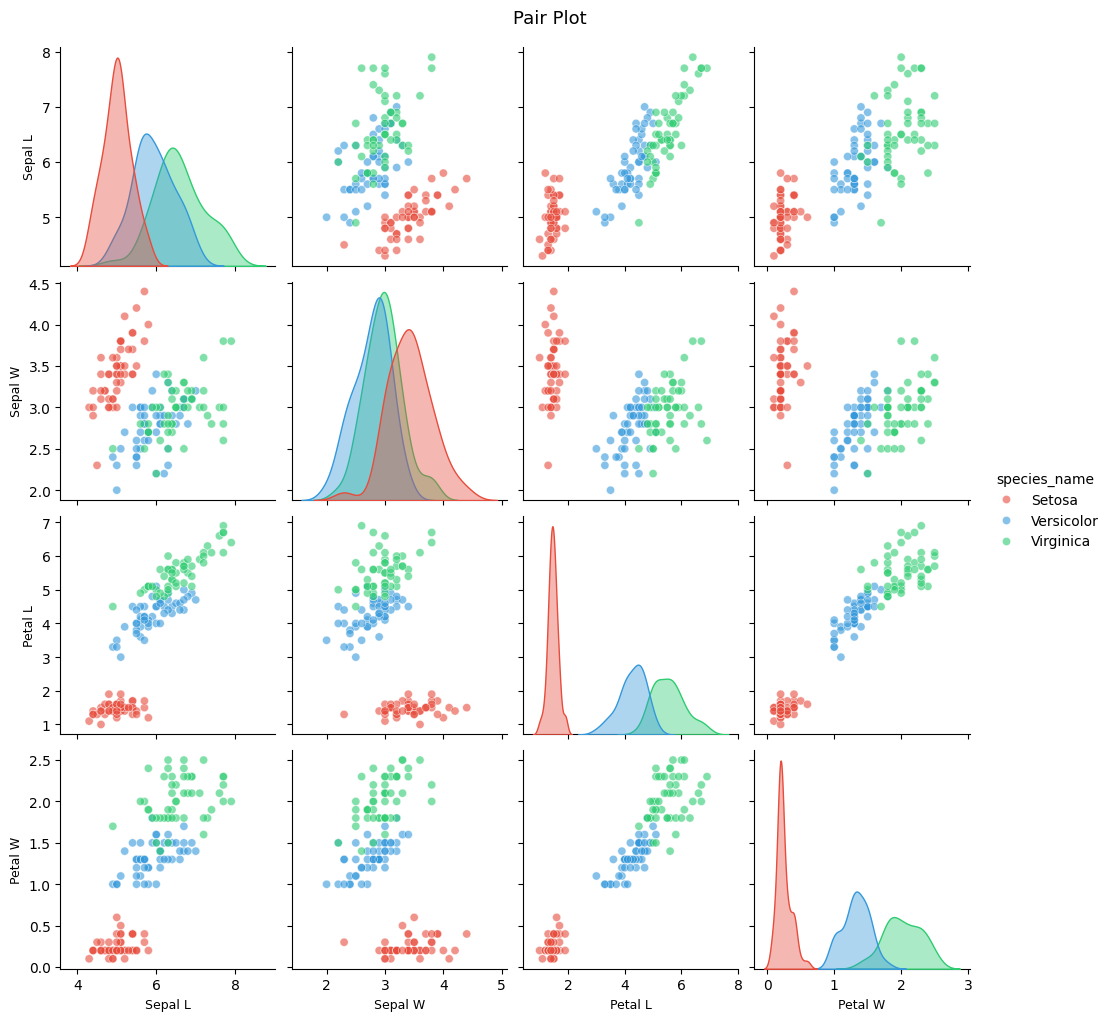

In [11]:
# 페어플롯 — 피처 조합 전체 확인
pair = sns.pairplot(
    df[FEATURES + ['species_name']],
    hue='species_name', palette=COLORS,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 35, 'edgecolor': 'white'},
    diag_kws={'fill': True, 'alpha': 0.4}
)
pair.figure.suptitle('Pair Plot', y=1.02, fontsize=13)

short = ['Sepal L','Sepal W','Petal L','Petal W']
for i, ax in enumerate(pair.axes[-1]): ax.set_xlabel(short[i], fontsize=9)
for i, ax in enumerate(pair.axes[:,0]): ax.set_ylabel(short[i], fontsize=9)

plt.show()

# Setosa는 petal 피처에서 완전히 분리
# Versicolor, Virginica는 petal 쪽에서 일부 겹침

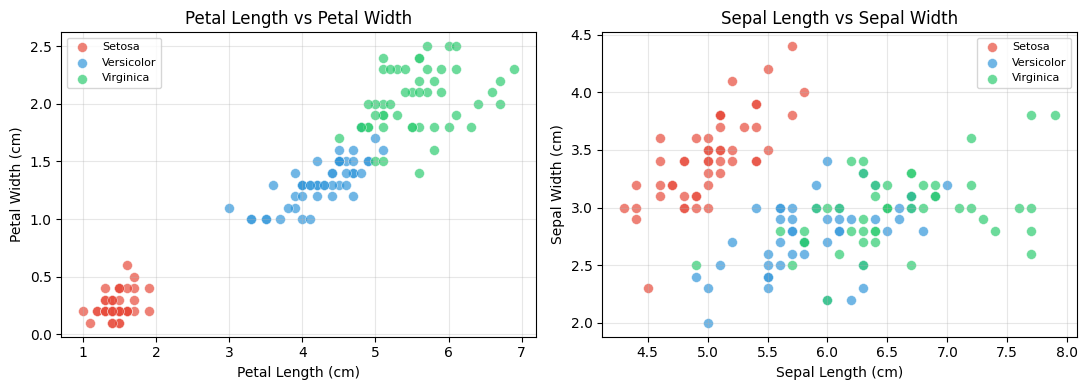

In [12]:
# 핵심 피처 산포도
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (xf, yf, title) in zip(axes, [
    ('petal_length', 'petal_width', 'Petal Length vs Petal Width'),
    ('sepal_length', 'sepal_width', 'Sepal Length vs Sepal Width'),
]):
    for sp, color in COLORS.items():
        sub = df[df['species_name']==sp]
        ax.scatter(sub[xf], sub[yf], c=color, label=sp,
                   alpha=0.7, s=50, edgecolors='white', linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel(xf.replace('_',' ').title() + ' (cm)')
    ax.set_ylabel(yf.replace('_',' ').title() + ' (cm)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 데이터 분리

학습 / 테스트 = 7:3, stratify로 품종 비율 유지

In [13]:
X = df[FEATURES].values
y = df['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape},  X_test: {X_test.shape}')
print(f'학습셋 분포: {np.bincount(y_train)}')
print(f'테스트셋 분포: {np.bincount(y_test)}')

X_train: (105, 4),  X_test: (45, 4)
학습셋 분포: [35 35 35]
테스트셋 분포: [15 15 15]


## 5. 피처 스케일링

KNN은 거리 기반 — 피처 스케일 차이에 민감하므로 StandardScaler 적용  
fit은 학습 데이터에만, 테스트는 transform만

In [14]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print('스케일링 후 평균:', X_train_std.mean(axis=0).round(4))
print('스케일링 후 표준편차:', X_train_std.std(axis=0).round(4))

스케일링 후 평균: [ 0. -0. -0. -0.]
스케일링 후 표준편차: [1. 1. 1. 1.]


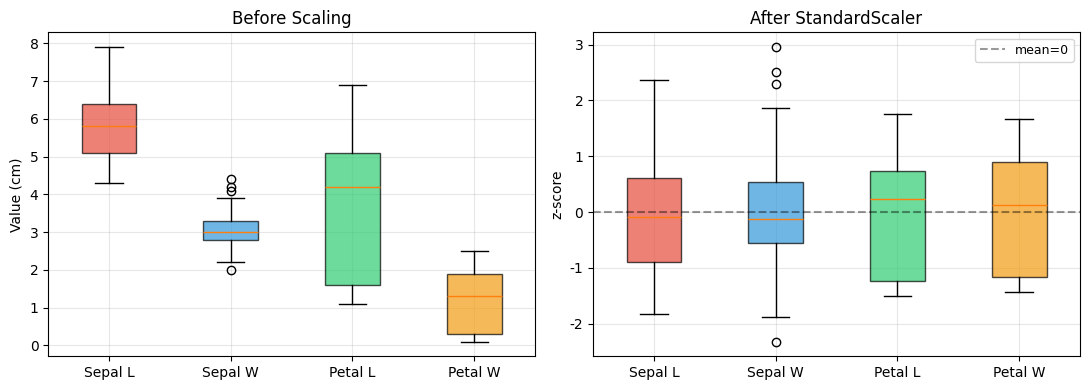

In [15]:
# 스케일링 전후 비교
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tick_names = ['Sepal L', 'Sepal W', 'Petal L', 'Petal W']
box_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

for ax, data, title, ylabel in zip(
    axes,
    [X_train, X_train_std],
    ['Before Scaling', 'After StandardScaler'],
    ['Value (cm)', 'z-score']
):
    bp = ax.boxplot(data, tick_labels=tick_names, patch_artist=True)
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axes[1].axhline(0, color='k', linestyle='--', alpha=0.4, label='mean=0')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. 모델링

k-NN 원리
- 새 데이터와 학습 데이터 간 거리 계산
- 가장 가까운 k개 이웃 선택
- 이웃 중 가장 많은 클래스로 분류 (다수결)

k 선택: k가 너무 작으면 과적합, 너무 크면 과소적합 → k=1~30 테스트

In [16]:
k_range = range(1, 31)
train_acc, test_acc = [], []

for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    m.fit(X_train_std, y_train)
    train_acc.append(m.score(X_train_std, y_train))
    test_acc.append(m.score(X_test_std, y_test))

best_k = list(k_range)[np.argmax(test_acc)]
print(f'최적 k: {best_k},  테스트 정확도: {max(test_acc):.4f}')

최적 k: 9,  테스트 정확도: 0.9556


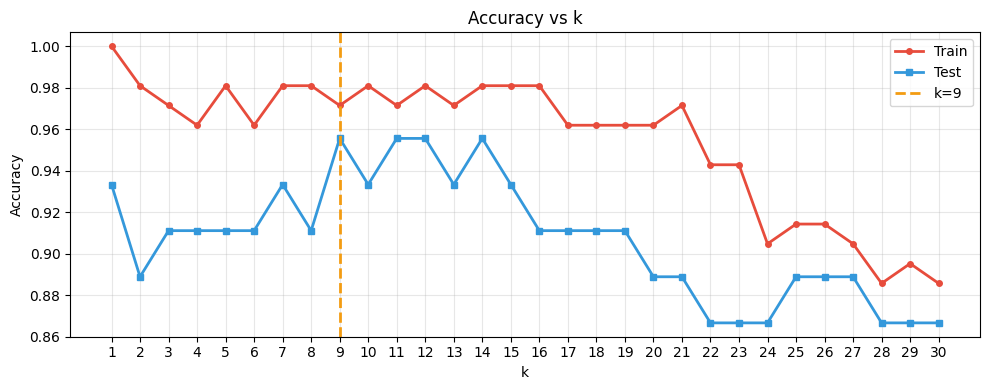

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_range, train_acc, 'o-', color='#E74C3C', lw=2, ms=4, label='Train')
ax.plot(k_range, test_acc,  's-', color='#3498DB', lw=2, ms=4, label='Test')
ax.axvline(best_k, color='#F39C12', linestyle='--', lw=2, label=f'k={best_k}')
ax.set_xlabel('k')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs k')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(range(1, 31))
plt.tight_layout()
plt.show()

In [18]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train_std, y_train)
print(knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=9)


## 7. 예측 및 평가

In [19]:
y_pred  = knn.predict(X_test_std)
y_proba = knn.predict_proba(X_test_std)

print(f'테스트 정확도: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

테스트 정확도: 0.9556

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [20]:
# 클래스별 확률 (앞 5개)
proba_df = pd.DataFrame(y_proba[:5], columns=['P(setosa)','P(versicolor)','P(virginica)'])
proba_df['predicted'] = [iris.target_names[p] for p in y_pred[:5]]
proba_df['actual']    = [iris.target_names[a] for a in y_test[:5]]
proba_df.round(3)

,P(setosa),P(versicolor),P(virginica),predicted,actual
0,0.0,0.000,1.000,virginica,virginica
1,0.0,1.000,0.000,versicolor,versicolor
2,0.0,0.667,0.333,versicolor,virginica
3,0.0,0.667,0.333,versicolor,versicolor
4,0.0,0.444,0.556,virginica,virginica


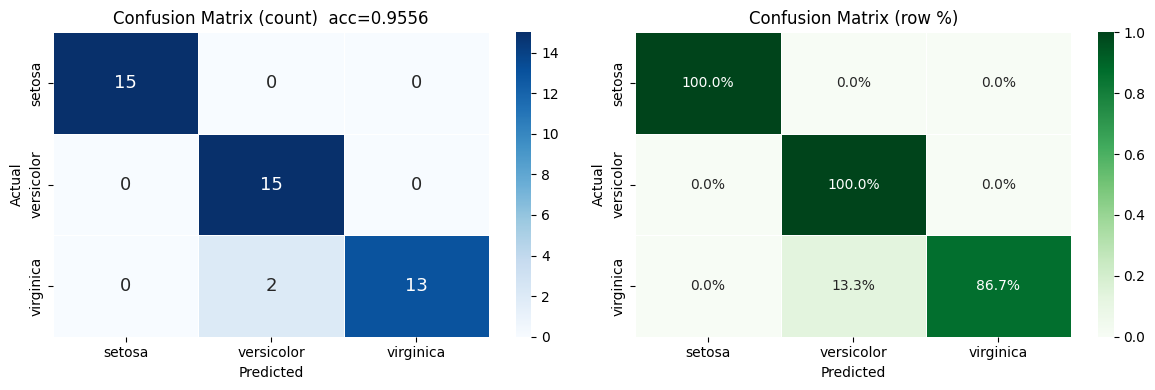

In [21]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            ax=axes[0], linewidths=0.5, annot_kws={'size':13})
axes[0].set_title(f'Confusion Matrix (count)  acc={accuracy_score(y_test,y_pred):.4f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (row %)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

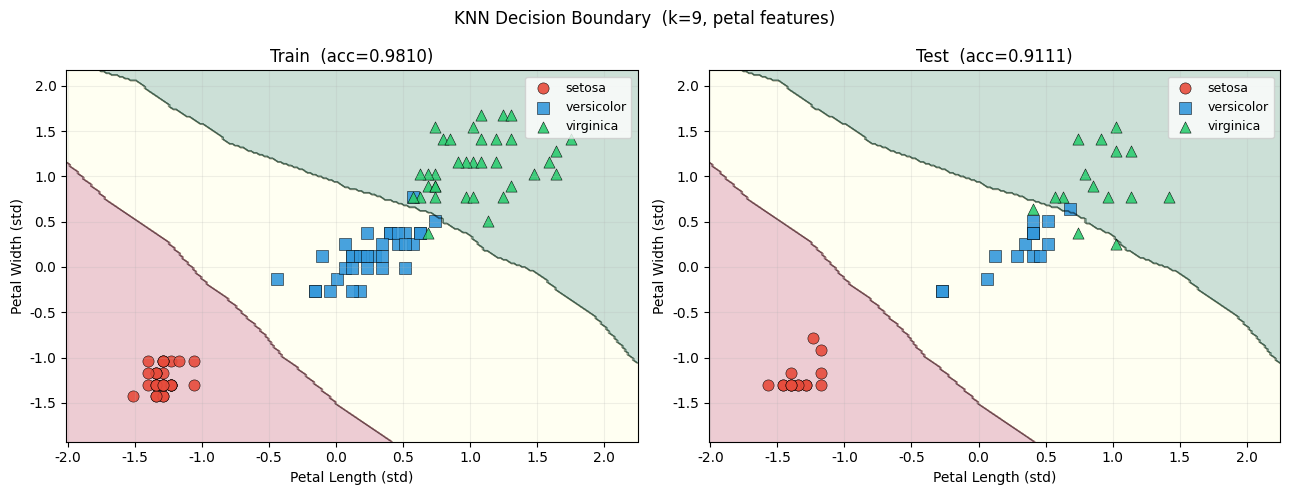

In [22]:
# 결정 경계 — petal 피처 2D로 시각화
X_2d = df[['petal_length','petal_width']].values
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)
sc2 = StandardScaler()
X_tr2_std = sc2.fit_transform(X_tr2)
X_te2_std = sc2.transform(X_te2)

knn2d = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn2d.fit(X_tr2_std, y_tr2)

h = 0.02
xx, yy = np.meshgrid(
    np.arange(X_tr2_std[:,0].min()-0.5, X_tr2_std[:,0].max()+0.5, h),
    np.arange(X_tr2_std[:,1].min()-0.5, X_tr2_std[:,1].max()+0.5, h)
)
Z = knn2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg  = matplotlib.colormaps.get_cmap('RdYlGn').resampled(3)
markers  = {0:'o', 1:'s', 2:'^'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'KNN Decision Boundary  (k={best_k}, petal features)', fontsize=12)

for ax, (Xp, yp, title) in zip(axes, [
    (X_tr2_std, y_tr2, 'Train'),
    (X_te2_std, y_te2, 'Test')
]):
    ax.contourf(xx, yy, Z, alpha=0.2, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.4, alpha=0.4)
    for label in range(3):
        mask = yp == label
        ax.scatter(Xp[mask,0], Xp[mask,1],
                   c=list(COLORS.values())[label],
                   marker=markers[label], label=iris.target_names[label],
                   s=65, edgecolors='black', linewidth=0.4, alpha=0.9)
    ax.set_title(f'{title}  (acc={knn2d.score(Xp,yp):.4f})')
    ax.set_xlabel('Petal Length (std)')
    ax.set_ylabel('Petal Width (std)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

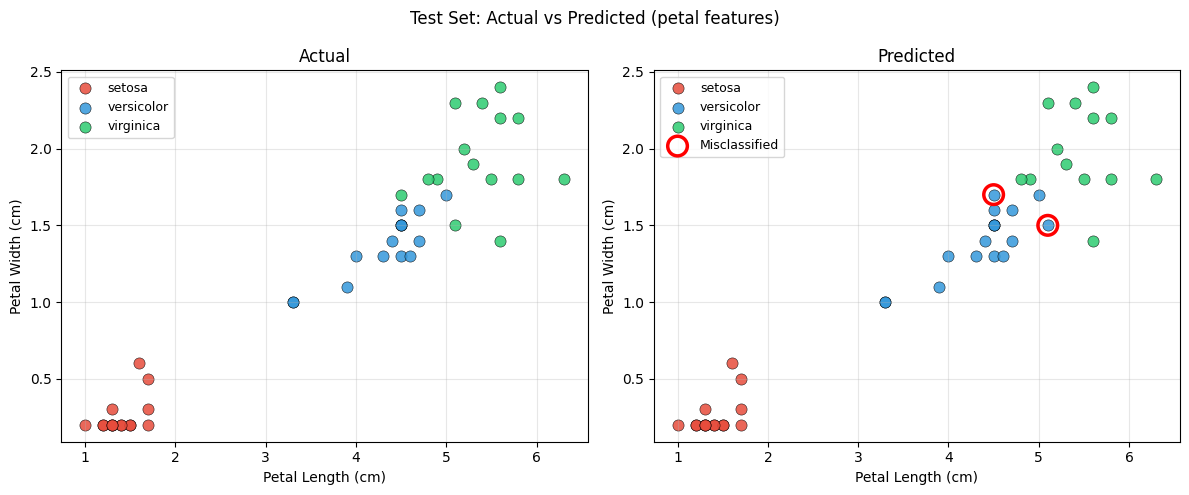

오분류: 2개 / 45개


In [23]:
# 테스트셋 예측 결과 — 오분류 위치 확인
wrong = y_pred != y_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Test Set: Actual vs Predicted (petal features)', fontsize=12)

for ax, (labels, title) in zip(axes, [(y_test,'Actual'), (y_pred,'Predicted')]):
    for label in range(3):
        mask = labels == label
        ax.scatter(X_test[mask,2], X_test[mask,3],
                   c=list(COLORS.values())[label],
                   label=iris.target_names[label],
                   s=65, edgecolors='black', linewidth=0.4, alpha=0.85)
    if title == 'Predicted' and wrong.sum() > 0:
        ax.scatter(X_test[wrong,2], X_test[wrong,3],
                   s=200, facecolors='none', edgecolors='red',
                   linewidth=2.5, zorder=5, label='Misclassified')
    ax.set_title(title)
    ax.set_xlabel('Petal Length (cm)')
    ax.set_ylabel('Petal Width (cm)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'오분류: {wrong.sum()}개 / {len(y_test)}개')

In [24]:
# 최종 정리
print(f'알고리즘 : KNeighborsClassifier')
print(f'k        : {best_k}')
print(f'거리     : euclidean')
print(f'스케일링 : StandardScaler')
print(f'train    : {knn.score(X_train_std, y_train):.4f}')
print(f'test     : {accuracy_score(y_test, y_pred):.4f}')
print(f'오분류   : {wrong.sum()}개 / {len(y_test)}개')

알고리즘 : KNeighborsClassifier
k        : 9
거리     : euclidean
스케일링 : StandardScaler
train    : 0.9714
test     : 0.9556
오분류   : 2개 / 45개
